# Records and Record Distributions

**If you haven't read [Getting Started](../tutorials/getting_started.ipynb)
or [Introduction to Distributions](01_distributions.ipynb), read those first.* 

As much as is possible, ProbPipe keeps *non-random* values (the Record family) and *random* values (the RecordDistribution family) aligned. 
Hence, they have the same conventions for accessing components/component information, and specialized support for the case when all components are numeric.  

|                       | Non-random (value)        | Random value               |
|-----------------------|---------------------------|-------------------------------------|
| **General leaves** | `Record`                  | `RecordDistribution`                |
| **Numeric leaves**    | `NumericRecord`           | `NumericRecordDistribution`         |


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (Record, NumericRecord, RecordArray, NumericRecordArray,
                      EventTemplate, NumericEventTemplate,
                      Normal, Bernoulli, Categorical, MultivariateNormal,
                      ProductDistribution, DistributionArray,
                      NumericRecordDistribution, sample, workflow_function)
from probpipe.custom_types import ArrayLike

# Part I — Values: the Record family

## 1. `Record` basics

Construct a `Record` by passing named fields. Leaves can be anything —
arrays, scalars, strings, xarray objects, or nested Records. 

In [2]:
params = Record(growth_rate=1.8, carrying_capacity=70.0)
print(params)
print("keys:", tuple(params.keys()))

Record(growth_rate=1.8, carrying_capacity=70.0)
keys: ('growth_rate', 'carrying_capacity')


Fields iterate in **insertion order** — the same order the keyword arguments were passed (or the order of the input dict). Access fields with `record["name"]`. 


In [3]:
print("growth_rate:", params["growth_rate"])
print("carrying_capacity:", params["carrying_capacity"])

growth_rate: 1.8
carrying_capacity: 70.0


The `Record` itself has the usual dict-like protocol: `len`, `in`, iteration,
`.keys()`, `.values()`, `.items()`.

In [4]:
print("len:", len(params))
print("growth_rate in params:", "growth_rate" in params)
for name, val in params.items():
    print(f"  {name} = {val}")

len: 2
growth_rate in params: True
  growth_rate = 1.8
  carrying_capacity = 70.0


### Heterogeneous leaves

Because `Record` stores leaves verbatim, fields can mix types freely:

In [5]:
observation = Record(counts=np.array([2, 1, 3, 0, 5]), label='horseshoe', duration=10.0)
print(observation)
print("counts:", observation["counts"])
print("label:", observation["label"])

Record(counts=array(shape=(5,)), label='horseshoe', duration=10.0)
counts: [2 1 3 0 5]
label: horseshoe


### Immutability

A `Record` is immutable. You can't reassign or delete a field:

In [6]:
try:
    params["growth_rate"] = 2.0
except TypeError as e:
    print("TypeError:", e)

TypeError: 'Record' object does not support item assignment


Instead, you build new Records from old ones with `replace`, `merge`,
and `without`. Each returns a new `Record` of the same class. In particular, the
operation is lossless for `NumericRecord` subclasses.

In [7]:
params2 = params.replace(growth_rate=2.0)
print("original:", params)
print("replaced:", params2)

original: Record(growth_rate=1.8, carrying_capacity=70.0)
replaced: Record(growth_rate=2.0, carrying_capacity=70.0)


`merge` combines two Records into one, adding fields from the right onto the left:

In [8]:
extra = Record(phi=10.0)
combined = params.merge(extra)
print("merged:", combined)

merged: Record(growth_rate=1.8, carrying_capacity=70.0, phi=10.0)


`without` drops a named field and returns a new Record:

In [9]:
reduced = combined.without("phi")
print("reduced:", reduced)

reduced: Record(growth_rate=1.8, carrying_capacity=70.0)


## 2. Nested Records

Fields can themselves be Records. This is useful when you want to group
related quantities — e.g., separating physical and statistics parameters in a likelihood.

In [10]:
data = Record(inputs=Record(force=1.2, mass=3.5), model_parameters=Record(sigma=0.1, rate=2.9))
print(data)

Record(inputs=Record(force=1.2, mass=3.5), model_parameters=Record(sigma=0.1, rate=2.9))


Bracket access with a string key is **leaf-keyed** — it reaches a field (leaf), not an interior node. To navigate to a nested sub-Record, use `at_path`:

In [11]:
print("inputs block:", data.at_path("inputs"))

inputs block: Record(force=1.2, mass=3.5)


For a nested **leaf**, index by its full path — either a `/`-joined string or a tuple, both reading left-to-right. To stop at an interior sub-Record instead, navigate with `at_path` and then index into it:

In [12]:
print("via path string:", data["inputs/force"])
print("via tuple:      ", data["inputs", "force"])
print("via at_path:    ", data.at_path("inputs")["force"])

via path string: 1.2
via tuple:       1.2
via at_path:     1.2


`jax.tree.map` walks through nested Records automatically (they're registered
as pytrees):

In [13]:
doubled = jax.tree.map(lambda x: x * 2.0, data)
print("doubled:", doubled)

doubled: Record(inputs=Record(force=2.4, mass=7.0), model_parameters=Record(sigma=0.2, rate=5.8))


## 3. `NumericRecord` — the numeric-leaves specialisation

`NumericRecord` is a `Record` subclass that validates every leaf at
construction time: each must be a numeric array, a numeric scalar, or a
nested `NumericRecord`. Non-numeric leaves raise `TypeError`. Numeric
leaves are coerced to `jnp.ndarray` so downstream JAX code sees a uniform
array type.

In [14]:
theta = NumericRecord(r=1.8, K=70.0, phi=10.0)
print(theta)
print("type of r:", type(theta["r"]).__name__)

NumericRecord(r=Array(1.8, dtype=float32, weak_type=True), K=Array(70., dtype=float32, weak_type=True), phi=Array(10., dtype=float32, weak_type=True))
type of r: ArrayImpl


Non-numeric leaves will raise an error:

In [15]:
try:
    NumericRecord(r=1.8, label="horseshoe")
except TypeError as e:
    print("TypeError:", e)

TypeError: NumericRecord: field 'label' must be a numeric array, numeric scalar, or nested NumericRecord, got str


### `flatten` and `unflatten`

`NumericRecord` has a 1-D vector representation obtained via `to_vector()`, which concatenates every leaf's raveled values in field-insertion order; `EventTemplate.from_vector(flat)` reverses the process. (The general JAX-pytree `flatten` / `unflatten` are separate ops that keep each leaf whole.)


In [16]:
params = NumericRecord(r=1.8, K=jnp.array([70.0, 72.0]), phi=10.0)
flat = params.to_vector()
print("vector_size:", params.vector_size)
print("flat vector:", flat)

vector_size: 4
flat vector: [ 1.8 70.  72.  10. ]


`vector_size` is cached at construction and matches `len(to_vector())`. It's
the number of scalar elements across every numeric leaf. This ise useful when
feeding the Record into an algorithm that wants a fixed-dimensional input
(MCMC samplers, optimisers, neural nets, etc.).

## 4. `EventTemplate` / `NumericEventTemplate` — the structural skeleton

`unflatten` needs to know the original field names and per-field shapes, since those are erased by flattening. An `EventTemplate` carries exactly that structural information with no data attached — it is ProbPipe's schema for a value. Every value exposes its own **authoritative** schema as `value.event_template` (inferred from the data when one wasn't supplied at construction, then cached). There are two closely related classes:

- **`EventTemplate`** — the general case. Each spec is either a shape tuple (numeric leaf), `None` (non-numeric leaf — string, label, any non-array data), or a nested sub-template. It is leaf-keyed: `keys()` lists the path to every leaf, in canonical order (and `values()` / `items()` follow the same order).
- **`NumericEventTemplate`** — the all-numeric specialisation. `None` specs are not allowed, so every leaf is a shape tuple or a nested `NumericEventTemplate`. Adds `vector_size` (total scalar count) and `leaf_shapes` (a path → shape dict), which are not well-defined in the general `EventTemplate` case — a non-array leaf has no shape.

`EventTemplate(...)` auto-promotes to `NumericEventTemplate` when every spec happens to be numeric, so it's not necessary to call it explicitly.

In [17]:
template = params.event_template
print("template:", template)
print("type:", type(template).__name__)
print("leaf shapes:", template.leaf_shapes)
print("vector_size:", template.vector_size)

template: NumericEventTemplate(r=(), K=(2,), phi=())
type: NumericEventTemplate
leaf shapes: {'r': (), 'K': (2,), 'phi': ()}
vector_size: 4


Round-trip:

In [18]:
restored = template.from_vector(flat)
print("restored:", restored)
print("equal to original:", restored == params)

restored: NumericRecord(r=Array(1.8, dtype=float32), K=array(shape=(2,)), phi=Array(10., dtype=float32))


equal to original: True


You can also build a template directly, without an example Record, which is useful
when describing the expected structure of a distribution's sample before
any draw has happened:

In [19]:
tpl = EventTemplate(r=(), K=(2,), phi=())
print("direct template:", tpl)
print("type:", type(tpl).__name__, "(auto-promoted — all specs numeric)")
print("vector_size:", tpl.vector_size)

direct template: NumericEventTemplate(r=(), K=(2,), phi=())
type: NumericEventTemplate (auto-promoted — all specs numeric)
vector_size: 4


### Numeric-only features

`NumericEventTemplate` carries two helpers beyond the base template:
`vector_size` (the total scalar count across all leaves) and
`leaf_shapes` (a path → shape dict, in canonical leaf order). Both are
well-defined exactly because every leaf is numeric — a mixed template's
leaves are enumerated by `keys()` instead (shapes aren't defined for
non-array leaves).

In [20]:
# Both extras live on the auto-promoted NumericEventTemplate from above.
print("vector_size:", tpl.vector_size)
print("leaf_shapes:", tpl.leaf_shapes)

# A template with an opaque (None) leaf stays on the base class, which
# enumerates its leaves with keys() (shapes aren't defined for opaque leaves):
mixed = EventTemplate(counts=(5,), label=None)
print("\nmixed template:", mixed)
print("type:          ", type(mixed).__name__)
print("leaf paths:    ", list(mixed.keys()))

vector_size: 4
leaf_shapes: {'r': (), 'K': (2,), 'phi': ()}

mixed template: EventTemplate(counts=(5,), label=None)
type:           EventTemplate
leaf paths:     ['counts', 'label']


### Nested templates

The specification for a field can be a tuple (numeric leaf), `None` (non-numeric leaf), or another template (nested structure). Similarly to Records, auto-promotion propagates: if every nested sub-template is numeric and the top-level specs are all numeric, the whole tree becomes a `NumericEventTemplate`.

In [21]:
nested_tpl = EventTemplate(inputs=EventTemplate(force=(), mass=()), obs=(5,))
print("nested template:", nested_tpl)
print("type:", type(nested_tpl).__name__)
print("vector_size:", nested_tpl.vector_size, "(2 scalars + 5-vector)")
print("flat leaf shapes:", nested_tpl.leaf_shapes)

nested template: NumericEventTemplate(inputs=NumericEventTemplate(force=(), mass=()), obs=(5,))
type: NumericEventTemplate
vector_size: 7 (2 scalars + 5-vector)
flat leaf shapes: {'inputs/force': (), 'inputs/mass': (), 'obs': (5,)}


## 5. Batches of Records: `RecordArray` and `NumericRecordArray`

ProbPipe has two batched forms, mirroring §1 vs §3:

- **`RecordArray`** — batches Records with any leaf type, including non-numeric data like labels.
- **`NumericRecordArray`** — the numeric-only specialisation; batches `NumericRecord`s and adds `to_vector` (1-D serialization) and reductions.

Use the general form when at least one field is non-numeric; use the numeric form when every field is a number or numeric array.

### General case: `RecordArray` with mixed leaves

You construct a `RecordArray` directly by passing each field's batched array, the `batch_shape`, and a `EventTemplate`. Here every row is one observation, with a string label, a count vector, and a numeric duration:

In [22]:
observations = RecordArray(
    counts=np.array([[2, 1, 3, 0, 5], [1, 0, 2, 1, 4]]),
    label=np.array(["fox", "hare"]),
    duration=np.array([10.0, 8.0]),
    batch_shape=(2,),
    template=EventTemplate(counts=(5,), label=None, duration=()),
)
print(observations)
print("type:", type(observations).__name__)
print("keys:", tuple(observations.keys()))

RecordArray(batch_shape=(2,), counts=array(shape=(2, 5)), label=array(shape=(2,)), duration=array(shape=(2,)))
type: RecordArray
keys: ('counts', 'label', 'duration')


A `RecordArray` supports two kinds of indexing:

- **String key** → returns that field across the whole batch (shape `(*batch_shape, *leaf_shape)`):
- **Integer index** → returns the single Record at that batch position:

In [23]:
print("observations['label']:", observations["label"])
print("observations[0]:    ", observations[0])

observations['label']: ['fox' 'hare']
observations[0]:     Record(counts=array(shape=(5,)), label=np.str_('fox'), duration=np.float64(10.0))


String keys index fields, integer indices index batch positions — they never collide, so you don't need to think about which dimension you meant.

### Numeric case: `NumericRecordArray` with reductions and flatten

When every field is numeric, use `NumericRecordArray`. You can construct one using `.stack()` on a list of `NumericRecord`s:

In [24]:
values = [NumericRecord(r=1.8 + 0.1 * i, K=70.0 + i, phi=10.0) for i in range(4)]
batch = NumericRecordArray.stack(values)
print("batch_shape:", batch.batch_shape)
print("template:", batch.template)
print(batch)

batch_shape: (4,)
template: NumericEventTemplate(r=(), K=(), phi=())
NumericRecordArray(batch_shape=(4,), r=array(shape=(4,)), K=array(shape=(4,)), phi=array(shape=(4,)))


`NumericRecordArray` adds two things `RecordArray` doesn't have: reductions across the batch (`mean`, `var`, ...) and `to_vector` (1-D serialization). Reductions return a `NumericRecord` if no batch dimension remains, or a smaller `NumericRecordArray` otherwise:

In [25]:
print("mean across draws:", batch.mean())
print("  type:", type(batch.mean()).__name__)
print("variance across draws:", batch.var())

mean across draws: NumericRecord(r=Array(1.9499999, dtype=float32), K=Array(71.5, dtype=float32), phi=Array(10., dtype=float32))
  type: NumericRecord


variance across draws: NumericRecord(r=Array(0.0125, dtype=float32), K=Array(1.25, dtype=float32), phi=Array(0., dtype=float32))


`flatten()` concatenates every field into a single trailing axis, preserving `batch_shape`:

In [26]:
flat_batch = batch.to_vector()
print("flattened shape:", flat_batch.shape)  # (4, 3) = (batch_size, flat_event_size)
print(flat_batch)

flattened shape: (4, 3)
[[ 1.8 70.  10. ]
 [ 1.9 71.  10. ]
 [ 2.  72.  10. ]
 [ 2.1 73.  10. ]]


Round-tripping through the flat representation works the same as for a single `NumericRecord`. The template describes the event structure, and batch dimensions are preserved automatically:

In [27]:
restored_batch = batch.template.from_vector(flat_batch)
print("restored:", restored_batch)
print("equal:", restored_batch == batch)

restored: NumericRecordArray(batch_shape=(4,), r=array(shape=(4,)), K=array(shape=(4,)), phi=array(shape=(4,)))
equal: True


If you omit `batch_shape`, `unflatten` infers it from `flat.shape[:-1]`:

In [28]:
inferred = batch.template.from_vector(flat_batch)
print("inferred batch_shape:", inferred.batch_shape)

inferred batch_shape: (4,)


**Nested fields carry through to arrays.** The nesting from §2 (and the
nested templates above) also works for batches: a `NumericRecordArray` whose
template has nested fields supports the same slash-path access as a `Record`
— `arr["outer/a"]` indexes a nested leaf across the whole batch — and
`flatten` / `unflatten` recurse into nested fields depth-first in leaf order,
so a nested batch round-trips through a single flat array just like the flat
case above. Build one by sampling a nested `ProductDistribution`, or with
`EventTemplate.from_vector` and a nested `EventTemplate`.

# Part II — Random: the RecordDistribution family

## 6. `RecordDistribution` — the random counterpart to `Record`

Most common distributions in ProbPipe are `RecordDistribution`, including the parametric and sampling families — `Normal`, `Beta`, `Bernoulli`, `MultivariateNormal`, `BootstrappedDistribution`, and so on. The same named-field API used for `Record` works on the distribution side too (`dist.fields`, `dist[name]`, `dist.select()`, `dist.select_all()`).

- **Single-component** distributions like `Normal` have one field. The field name comes from the `name=` you pass at construction.
- **Multi-component** joints — `ProductDistribution`, `SequentialJointDistribution`, `JointGaussian`, `JointEmpirical` — bundle several random variables under one distribution with one field per component. They're covered in depth in the [joint distributions notebook](04_joint_distributions.ipynb).

The same field-access pattern works on either kind:

In [29]:
# A single-field distribution: Normal has one field, named at construction.
n = Normal(loc=0.0, scale=1.0, name="height")
print("Normal:")
print("  fields:        ", n.fields)
print("  n['height']:   ", type(n["height"]).__name__, "(a view)")
print("  select_all:    ", list(n.select_all()))

# A multi-field joint: ProductDistribution gives you several named components.
prior = ProductDistribution(Normal(loc=0.0, scale=3.0, name="growth_rate"),
                            Normal(loc=70.0, scale=10.0, name="carrying_capacity"))
print("\nProductDistribution:")
print("  fields:        ", prior.fields)
print("  prior['growth_rate']:", type(prior["growth_rate"]).__name__)
print("  select_all:    ", list(prior.select_all()))

Normal:
  fields:         ('height',)
  n['height']:    _RecordDistributionView (a view)
  select_all:     ['height']



ProductDistribution:
  fields:         ('growth_rate', 'carrying_capacity')
  prior['growth_rate']: _RecordDistributionView
  select_all:     ['growth_rate', 'carrying_capacity']


`dist[name]` and the values returned by `dist.select_all()` are lightweight *views* on the parent distribution. When you pass two views from the same parent into a `@workflow_function`, they stay correlated: the parent gets sampled once per draw, and each view pulls its component from the shared draw. See [Broadcasting and workflow functions](03_broadcasting.ipynb) for details.

## 7. `NumericRecordDistribution` — the numeric specialisation

`NumericRecordDistribution` is to `RecordDistribution` what `NumericRecord` is to `Record`: every field is a numeric random variable. All of the standard families (`Normal`, `Beta`, `Bernoulli`, `MultivariateNormal`, ...) are single-field `NumericRecordDistribution`s, and most joints you'll build are numeric too.

Each piece of numeric metadata comes in a **canonical / convenience** pair.
The convenience accessors are shortcuts for the common single-field case. 
Use the canonical ones when you have multiple fields and need them keyed per-field:

| Concept   | Canonical (per-field, multi-leaf safe) | Convenience (single-field, scalar) |
|-----------|----------------------------------------|------------------------------------|
| Shape     | `event_shapes : dict`                  | `event_shape : tuple`              |
| Dtype     | `dtypes : dict`                        | `dtype` (or `None` if mixed)       |
| Support   | `supports : dict`                      | `support : Constraint`             |



In [30]:
n = Normal(loc=0.0, scale=1.0, name="x")

# Canonical (per-field).
print("event_shapes:", n.event_shapes)
print("dtypes:      ", n.dtypes)
print("supports:    ", n.supports)

# Convenience (single-field shortcut).
print("\nevent_shape:", n.event_shape)
print("dtype:       ", n.dtype)
print("support:     ", n.support)

event_shapes: {'x': ()}
dtypes:       {'x': <class 'numpy.float32'>}
supports:     {'x': real}

event_shape: ()
dtype:        <class 'numpy.float32'>
support:      real


Integer-valued distributions report integer dtypes:

In [31]:
print("Bernoulli.dtype:   ", Bernoulli(probs=0.5, name="x").dtype)
print("Categorical.dtype: ", Categorical(probs=jnp.array([0.5, 0.5]), name="x").dtype)
print("Normal.dtype:      ", Normal(loc=0.0, scale=1.0, name="x").dtype)

Bernoulli.dtype:    <class 'jax.numpy.int32'>
Categorical.dtype:  <class 'jax.numpy.int32'>
Normal.dtype:       <class 'numpy.float32'>


For single-field distributions, the `EventTemplate` is auto-built from `name=` and `event_shape`. You almost never need to construct one by hand:

In [32]:
mvn = MultivariateNormal(loc=jnp.zeros(3), cov=jnp.eye(3), name="z")
print("event_template:", mvn.event_template)
print("event_shapes:   ", mvn.event_shapes)

event_template: NumericEventTemplate(z=(3,))
event_shapes:    {'z': (3,)}


## 8. Samples bridge to the value side

What does `sample(dist)` give you back? It depends on whether the distribution has one field or several:

- **Single-field** (`Normal`, `MultivariateNormal`, ...) → a raw `jax.Array` of shape `sample_shape + event_shape`.
- **Multi-field** (`ProductDistribution`, ...) → a `Record` (or `NumericRecordArray` if you asked for several samples), keyed by `dist.fields`.

That way, the result you get back already has the right shape and naming to flow into the rest of your workflow — no manual repackaging.

In [33]:
# Single-field → array.
n = Normal(loc=0.0, scale=1.0, name="x")
print("Normal sample type:    ", type(sample(n)).__name__)

# Multi-field → Record.
prior = ProductDistribution(
    Normal(loc=0.0, scale=3.0, name="growth_rate"),
    Normal(loc=70.0, scale=10.0, name="carrying_capacity"),
)
draw = sample(prior)
print("ProductDistribution sample type:", type(draw).__name__)
print("  keys:", tuple(draw.keys()))
print("  growth_rate:", float(draw['growth_rate']))

Normal sample type:     NumericRecord
ProductDistribution sample type: Record
  keys: ('growth_rate', 'carrying_capacity')
  growth_rate: 1.5958120822906494


# Part III — Tying the two families together

## 9. The value ↔ distribution correspondence

Here's the same 2×2 table from the overview, but now with concrete examples:

|                       | Non-random (value)                                       | Random (one variable)                                          |
|-----------------------|----------------------------------------------------------|----------------------------------------------------------------|
| **Permissive leaves** | `Record(label='horseshoe', count=5)`                     | `ProductDistribution(Normal(..., name="theta"), ...)` (mixed)   |
| **Numeric leaves**    | `NumericRecord(r=1.8, K=70.0)`                           | `ProductDistribution(Normal(..., name=r), Normal(..., name=K))`            |

Because the field API is the same on both sides, the same `**dist.select_all()` call works whether `dist` is fixed or random. When it's fixed, the function runs once with concrete values; when it's a distribution, the workflow function layer draws samples over them for you.

In [34]:
@workflow_function
def predict(growth_rate: ArrayLike, carrying_capacity: ArrayLike, x: ArrayLike) -> ArrayLike:
    return carrying_capacity / (1 + jnp.exp(-growth_rate * x))

x = jnp.linspace(-2.0, 2.0, 10)

# Fixed Record → one concrete evaluation. `predict` is a WorkflowFunction,
# so even with concrete values the output is a NumericRecord named after
# the function.
fixed = NumericRecord(growth_rate=1.8, carrying_capacity=70.0)
y_fixed = predict(**fixed.select_all(), x=x)
print("predict on fixed values:  ", y_fixed["predict"])

# Random RecordDistribution → same call signature; the WF layer threads
# prior samples through `predict` and returns a pushforward distribution.
prior = ProductDistribution(Normal(loc=0.0, scale=3.0, name="growth_rate"),
                            Normal(loc=70.0, scale=10.0, name="carrying_capacity"))
y_prior = predict(**prior.select_all(), x=x)
print()
print("predict on prior:         ", y_prior)
print("one draw from prior:      ", sample(y_prior)["marginal"])

predict on fixed values:   [ 1.8617897  4.0126925  8.344205  16.203268  28.091862  41.90814
 53.796734  61.655792  65.987305  68.138214 ]



predict on prior:          MarginalizedBroadcastDistribution(num_atoms=128, fields=(marginal))


one draw from prior:       [47.85262   45.00717   41.04221   35.903458  29.834564  23.406576
 17.337679  12.198934   8.23397    5.3885226]


What's inside that `MarginalizedBroadcastDistribution`? Each of the `n=128` cached samples is one prediction curve — sampled by drawing `(growth_rate, carrying_capacity)` from the prior and pushing the pair through `predict`. Plotting a chunk of them makes the prior predictive uncertainty clear:

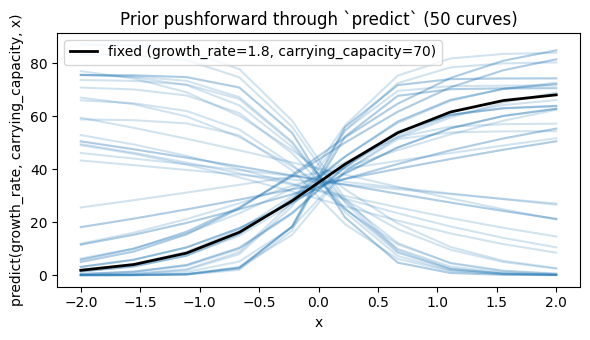

In [35]:
# 50 curves from the prior predictive.
prior_curves = sample(y_prior, sample_shape=(50,))["marginal"]

fig, ax = plt.subplots(figsize=(6, 3.5))
for curve in prior_curves:
    ax.plot(x, curve, color="C0", alpha=0.2)
ax.plot(x, y_fixed["predict"], color="black", lw=2,
        label="fixed (growth_rate=1.8, carrying_capacity=70)")
ax.set_xlabel("x")
ax.set_ylabel("predict(growth_rate, carrying_capacity, x)")
ax.set_title("Prior pushforward through `predict` (50 curves)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 10. `DistributionArray` — array of distributions

`DistributionArray` is the distribution-side counterpart to `RecordArray`: an array (or grid) of independent scalar distributions, indexed positionally rather than by field name.

One asymmetry to know about: a `RecordArray` *is* a `Record` whose leaves happen to be batched, but a `DistributionArray` is *not* a `RecordDistribution` — each cell is its own scalar `Distribution`. So:

- Reach for a `DistributionArray` when you want an array of independent distributions (e.g., 50 independent priors for 50 parameters).
- Reach for a `RecordDistribution` when you want one random variable with named components.

The natural constructor is `from_batched_params`, which takes a distribution class and batched parameters:

In [36]:
da = DistributionArray.from_batched_params(
    Normal, loc=jnp.arange(5.0), scale=1.0, name="x",
)
print("DistributionArray:", da)
print("  batch_shape:", da.batch_shape)
print("  size:       ", da.size)
print("  len:        ", len(da))
print("  da[2].loc:  ", float(da[2].loc))

DistributionArray: DistributionArray(batch_shape=(5,), event_shape=() backend=True)
  batch_shape: (5,)
  size:        5
  len:         5
  da[2].loc:   2.0


`len` and iteration follow consistent conventions across the family:

- `len(record)` — number of fields.
- `len(record_array)` — leading-axis batch size (matches `np.zeros(batch_shape).__len__`).
- `len(distribution_array)` — same: leading-axis batch size.

Records and RecordArrays iterate field names dict-style; `DistributionArray` iterates leading-axis slices like a numpy array.

The [broadcasting notebook](03_broadcasting.ipynb) covers how `DistributionArray` flows through `@workflow_function` calls. The four `RecordDistribution` joint flavours each get their own walk in the [joint distributions notebook](04_joint_distributions.ipynb).

## 11. JAX interop carries through both sides

Every Record class is registered as a JAX pytree — field names as aux data, leaves as children — so they flow transparently through every JAX transform.

In [37]:
# jax.tree.map walks into the Record
theta = NumericRecord(r=1.8, K=70.0)
print("log params:", jax.tree.map(jnp.log, theta))

log params: NumericRecord(r=Array(0.5877866, dtype=float32, weak_type=True), K=Array(4.248495, dtype=float32, weak_type=True))


`jit` works because Records are pytrees: the static structure (field names) becomes aux data, so two Records with matching field names share a traced function.

In [38]:
@jax.jit
def logistic(theta):
    """Population at equilibrium given logistic parameters."""
    return theta["K"] * jnp.exp(theta["r"])

print("logistic(theta) =", logistic(theta))

logistic(theta) = 423.4753


The same jitted function broadcasts automatically over a `NumericRecordArray`: every field is already a batched array, so JAX vectorises the arithmetic for free.

In [39]:
theta_batch = NumericRecordArray.stack([NumericRecord(r=0.1 * i, K=70.0 + i) for i in range(5)])
print("logistic(theta_batch):", logistic(theta_batch))

logistic(theta_batch): [ 70.        78.46714   87.941     98.539696 110.395035]


## 12. Round-tripping xarray and pandas

ProbPipe's native array form is `jax.Array`, but you'll often build a `Record` from richer backends — an `xarray.DataArray` with dims and coords, a `pandas.Series` with a `DatetimeIndex`. The aux registry in `probpipe.core._array_backend` captures backend-specific metadata so a `Record` → `NumericRecord` → `Record` round-trip restores the original objects.

In [40]:
import xarray as xr

da = xr.DataArray(
    np.array([[1.0, 2.0], [3.0, 4.0]]),
    dims=("time", "species"),
    coords={"time": [0.0, 1.0], "species": ["fox", "hare"]},
    name="counts",
)
obs = Record(counts=da)

# Forward: convert to JAX-native form. Aux is captured per leaf.
numeric = obs.to_numeric()  # NumericRecord — every leaf is jax.Array
print("numeric[counts].dtype:", numeric["counts"].dtype)
print("numeric.aux keys:    ", list((numeric.aux or {}).keys()))

# Reverse: restore each leaf to its original backend.
back = numeric.to_native()
print("back[counts]:")
print(back["counts"])


numeric[counts].dtype: float32
numeric.aux keys:     ['counts']
back[counts]:
<xarray.DataArray 'counts' (time: 2, species: 2)> Size: 16B
array([[1., 2.],
       [3., 4.]], dtype=float32)
Coordinates:
  * time     (time) float64 16B 0.0 1.0
  * species  (species) <U4 32B 'fox' 'hare'


Aux is a snapshot at construction. Any transform that rebuilds the record (`record.map`, `record.replace`, `jax.tree.map`) drops it, and the transformed leaves come back as plain `jax.Array`. To register backends beyond the built-in xarray / pandas hooks, call `probpipe.register_aux(...)`.

## Summary

| Need | Reach for |
|---|---|
| One named, immutable, non-random struct | `Record` |
| Same, numeric leaves, with `flatten` / single-field array shim | `NumericRecord` |
| Batch of those | `RecordArray` / `NumericRecordArray` |
| One single-component random variable | A standard distribution like `Normal`, `Beta`, `MultivariateNormal` — all single-field `NumericRecordDistribution`s |
| Multi-component joint with named random components | A joint flavour — `ProductDistribution`, `JointGaussian`, `JointEmpirical`, `SequentialJointDistribution` |
| Array of independent scalar distributions | `DistributionArray.from_batched_params(...)` (or as a WF-sweep output) |

The natural next step is the [broadcasting notebook](03_broadcasting.ipynb), which covers how `@workflow_function` threads Records and RecordDistributions into a pipeline. The four `RecordDistribution` joint flavours each get their own walk in the [joint distributions notebook](04_joint_distributions.ipynb).